# Tech Challenge Fase 1 — Case NPS Preditivo
### FIAP PosTech | Ciência de Dados e Inteligência Artificial

**Objetivo:** Analisar dados operacionais de um e-commerce para identificar os fatores que impactam a satisfação do cliente (NPS) e propor estratégias preditivas para antecipar problemas antes da pesquisa ser aplicada.

---
*Dataset: `desafio_nps_fase_1.csv` — dados históricos de pedidos, logística e atendimento*

# 1. Análise Exploratória dos Dados (EDA)

> *Foco em negócio: os resultados devem ser compreensíveis para um gerente de operações que não entende estatística.*

A EDA está organizada nas seguintes seções:
- **1.1** Visão Geral dos Dados
- **1.2** Distribuição do NPS — Quem são os detratores?
- **1.3** Análise Logística — O impacto da entrega
- **1.4** Análise de Atendimento — Contatos e resolução
- **1.5** Perfil do Cliente
- **1.6** Correlações — O que mais explica o NPS?
- **1.7** Pontos de Ruptura — Onde a experiência quebra?
- **1.8** Insights de Negócio — Resumo executivo

In [1]:
# =============================================================================
# CONFIGURAÇÕES E IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("✓ Bibliotecas carregadas com sucesso!")

✓ Bibliotecas carregadas com sucesso!


In [2]:
# =============================================================================
# CARREGAMENTO DOS DADOS
# =============================================================================


# Carregando o dataset 
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

print(f"✓ Dataset carregado com sucesso!")
print(f"  Dimensões: {df.shape[0]:,} registros x {df.shape[1]} colunas")
print(f"\nColunas disponíveis:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

df.head()

✓ Dataset carregado com sucesso!
  Dimensões: 2,500 registros x 19 colunas

Colunas disponíveis:
  - customer_id (int64)
  - customer_age (int64)
  - customer_region (object)
  - customer_tenure_months (int64)
  - order_id (int64)
  - order_value (float64)
  - items_quantity (int64)
  - discount_value (float64)
  - payment_installments (int64)
  - delivery_time_days (int64)
  - delivery_delay_days (int64)
  - freight_value (float64)
  - delivery_attempts (int64)
  - customer_service_contacts (int64)
  - resolution_time_days (int64)
  - nps_score (float64)
  - repeat_purchase_30d (int64)
  - complaints_count (int64)
  - csat_internal_score (float64)


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 1.1 Visão Geral dos Dados

In [3]:
# Informações gerais e estatísticas descritivas
print("=" * 65)
print("TIPOS DE DADOS E CONTAGEM DE NÃO-NULOS")
print("=" * 65)
df.info()

print("\n" + "=" * 65)
print("ESTATÍSTICAS DESCRITIVAS — VARIÁVEIS NUMÉRICAS")
print("=" * 65)
df.describe().round(2)

TIPOS DE DADOS E CONTAGEM DE NÃO-NULOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [4]:
# Verificação de valores ausentes e duplicatas
print("VALORES AUSENTES POR COLUNA:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '% Ausentes': missing_pct})
problemas = missing_df[missing_df['Ausentes'] > 0]

if problemas.empty:
    print("  Nenhum valor ausente encontrado — dataset completo.")
else:
    print(problemas)

print(f"\nDuplicatas: {df.duplicated().sum()} registros duplicados")

# Distribuição da variável categórica
print(f"\nDistribuição por Região (customer_region):")
print(df['customer_region'].value_counts().to_string())
print(f"\nFaixa do NPS Score: {df['nps_score'].min():.1f} — {df['nps_score'].max():.1f}")
print(f"NPS médio: {df['nps_score'].mean():.2f} | Mediana: {df['nps_score'].median():.2f}")

VALORES AUSENTES POR COLUNA:
  Nenhum valor ausente encontrado — dataset completo.

Duplicatas: 0 registros duplicados

Distribuição por Região (customer_region):
customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468

Faixa do NPS Score: 0.0 — 10.0
NPS médio: 4.38 | Mediana: 4.40


## 1.2 Distribuição do NPS — Quem são os Detratores?

**Classificação adotada (escala 0–10):**
- **Detratores:** NPS < 7 — clientes insatisfeitos, em risco de churn e reviews negativos
- **Passivos:** 7 ≤ NPS ≤ 8 — satisfeitos, mas vulneráveis à concorrência
- **Promotores:** NPS > 8 — leais, propensos a recomendar e recomprar

COMPOSIÇÃO DO NPS:
  Detrator  :  2109 clientes ( 84.4%)
  Passivo   :   190 clientes (  7.6%)
  Promotor  :   201 clientes (  8.0%)

NPS Score da empresa: -76.3 pontos


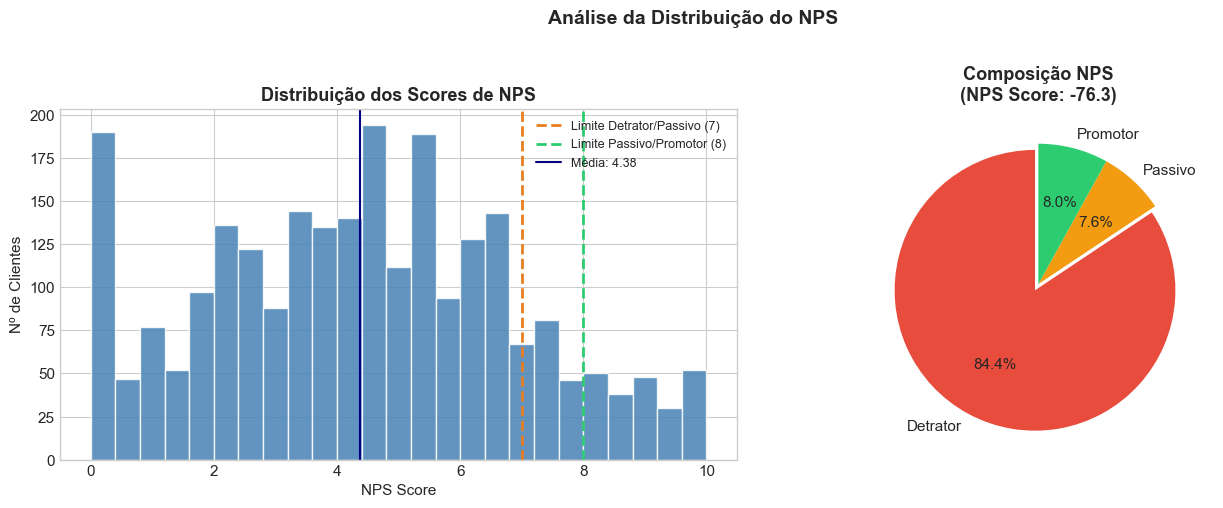


→ INSIGHT: 84.4% dos clientes são detratores — foco principal de ação.


In [5]:
# Classificação NPS e cálculo do NPS Score da empresa
def classificar_nps(score):
    if score < 7:
        return 'Detrator'
    elif score <= 8:
        return 'Passivo'
    else:
        return 'Promotor'

df['nps_categoria'] = df['nps_score'].apply(classificar_nps)

nps_dist = df['nps_categoria'].value_counts()
nps_pct  = df['nps_categoria'].value_counts(normalize=True) * 100

print("COMPOSIÇÃO DO NPS:")
for cat in ['Detrator', 'Passivo', 'Promotor']:
    n   = nps_dist.get(cat, 0)
    pct = nps_pct.get(cat, 0)
    print(f"  {cat:10s}: {n:>5} clientes ({pct:5.1f}%)")

n_prom = nps_dist.get('Promotor', 0)
n_detr = nps_dist.get('Detrator', 0)
nps_metric = ((n_prom - n_detr) / len(df)) * 100
print(f"\nNPS Score da empresa: {nps_metric:.1f} pontos")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['nps_score'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=7, color='#e67e22', linestyle='--', linewidth=2, label='Limite Detrator/Passivo (7)')
axes[0].axvline(x=8, color='#2ecc71', linestyle='--', linewidth=2, label='Limite Passivo/Promotor (8)')
axes[0].axvline(x=df['nps_score'].mean(), color='navy', linestyle='-', linewidth=1.5,
                label=f'Média: {df["nps_score"].mean():.2f}')
axes[0].set_xlabel('NPS Score')
axes[0].set_ylabel('Nº de Clientes')
axes[0].set_title('Distribuição dos Scores de NPS')
axes[0].legend(fontsize=9)

# Pizza
cat_order  = ['Detrator', 'Passivo', 'Promotor']
cat_counts = [nps_dist.get(c, 0) for c in cat_order]
axes[1].pie(cat_counts,
            labels=cat_order,
            colors=['#e74c3c', '#f39c12', '#2ecc71'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0.05, 0, 0))
axes[1].set_title(f'Composição NPS\n(NPS Score: {nps_metric:.1f})')

plt.suptitle('Análise da Distribuição do NPS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n→ INSIGHT: {nps_pct.get('Detrator', 0):.1f}% dos clientes são detratores — foco principal de ação.")

→ INSIGHT: 84.4% dos clientes são detratores — foco principal de ação.


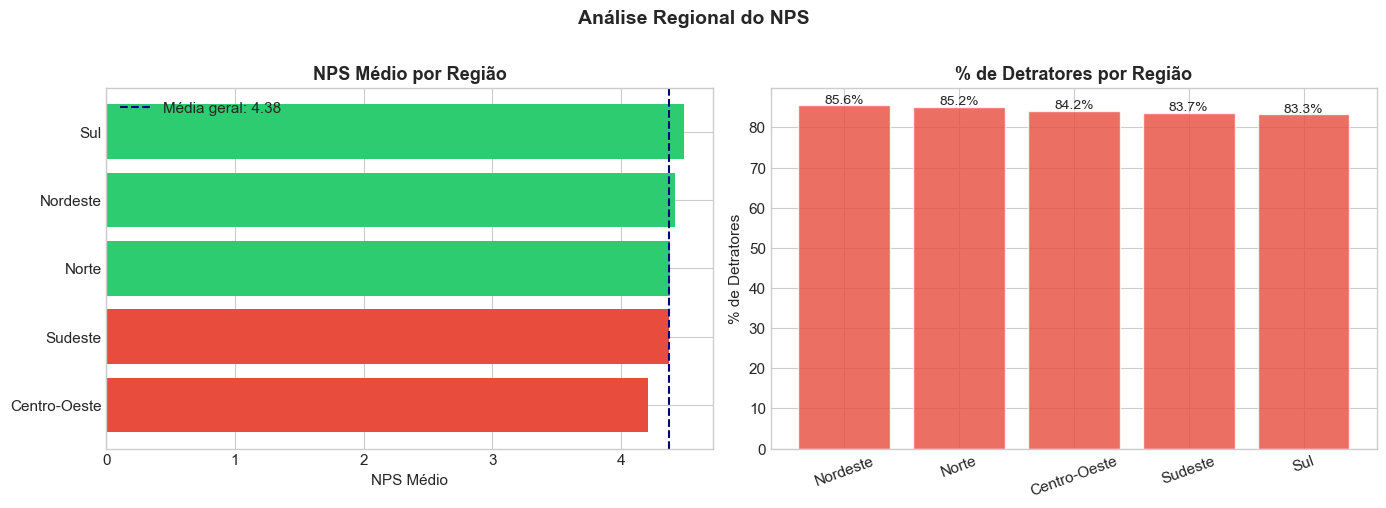


NPS médio por região (ordenado do pior ao melhor):
customer_region
Centro-Oeste    4.209829
Sudeste         4.373846
Norte           4.382609
Nordeste        4.421649
Sul             4.490979


In [6]:
# NPS por Região
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

media_geral = df['nps_score'].mean()

# NPS médio por região
nps_regiao = df.groupby('customer_region')['nps_score'].mean().sort_values()
cores = ['#e74c3c' if v < media_geral else '#2ecc71' for v in nps_regiao.values]
axes[0].barh(nps_regiao.index, nps_regiao.values, color=cores)
axes[0].axvline(x=media_geral, color='navy', linestyle='--', linewidth=1.5,
                label=f'Média geral: {media_geral:.2f}')
axes[0].set_xlabel('NPS Médio')
axes[0].set_title('NPS Médio por Região')
axes[0].legend()

# % de Detratores por região
detr_regiao = (df.groupby('customer_region')
               .apply(lambda x: (x['nps_categoria'] == 'Detrator').mean() * 100)
               .sort_values(ascending=False))
axes[1].bar(detr_regiao.index, detr_regiao.values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_ylabel('% de Detratores')
axes[1].set_title('% de Detratores por Região')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(detr_regiao.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Análise Regional do NPS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nNPS médio por região (ordenado do pior ao melhor):")
print(nps_regiao.to_string())

## 1.3 Análise Logística — O Impacto da Entrega no NPS

**O que os dados mostram:** O **atraso na entrega** é o driver logístico mais forte de insatisfação (r = −0,60). O **tempo total de entrega** (r ≈ 0,00) e o **número de tentativas de entrega** (r = +0,03) **não têm correlação relevante** com o NPS. O que importa não é o prazo absoluto, mas o cumprimento do prazo prometido ao cliente. Este impacto no NPS deve-se ao fato da forma como o score é calculado, onde um detrator de nota 6 tem o mesmo peso de um detrator de nota 1.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


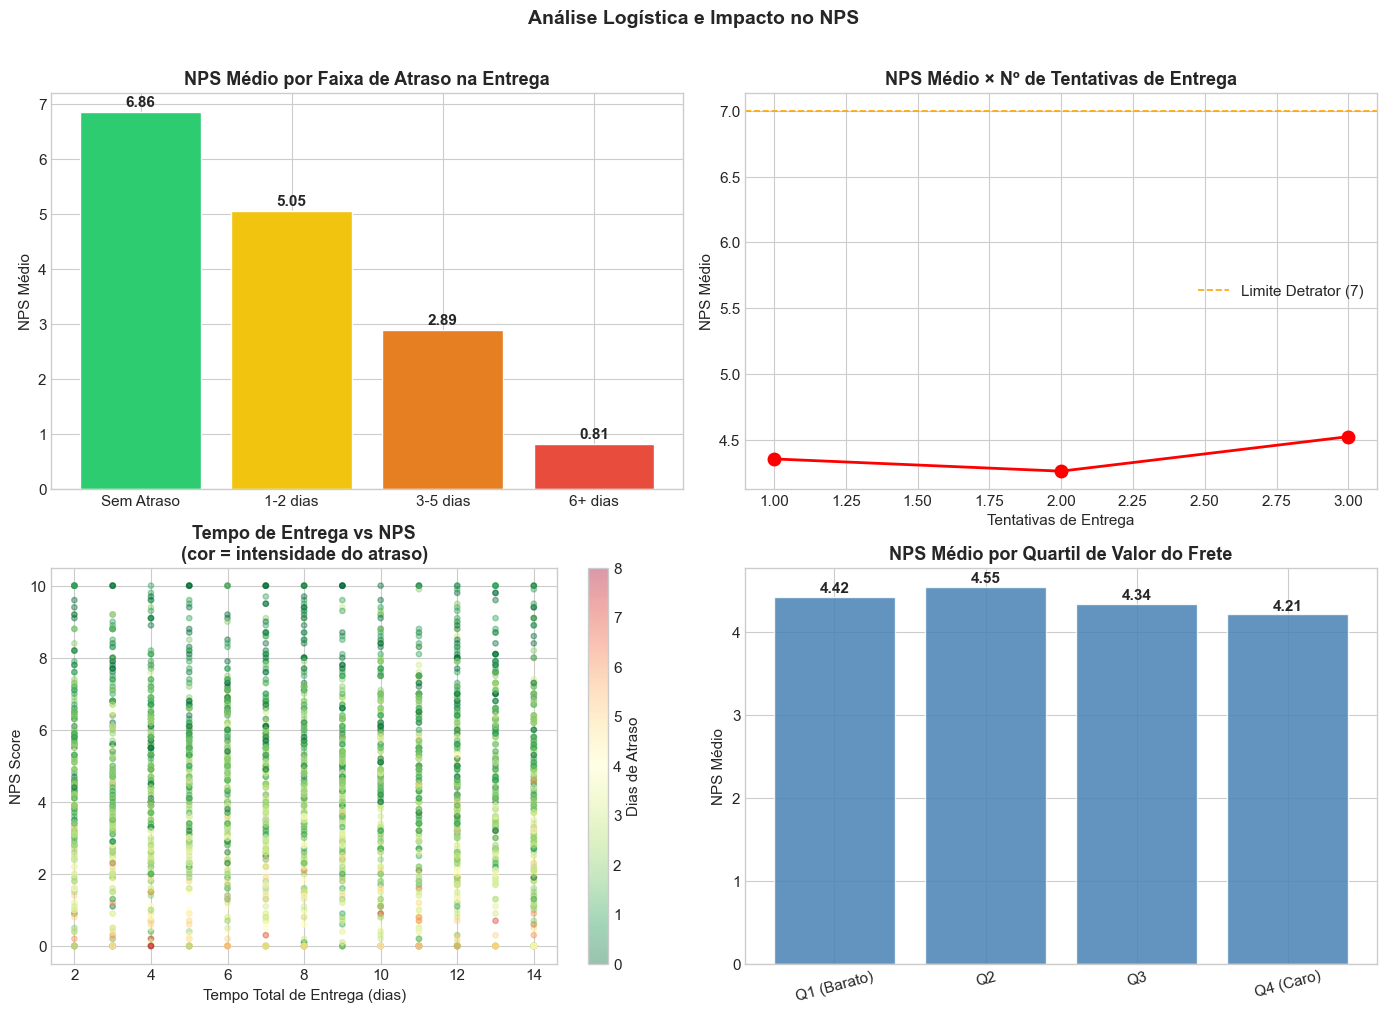

CORRELAÇÕES COM NPS SCORE:
  Atraso na entrega    : r = -0.597  (p = 0.0000)
  Tempo total entrega  : r = +0.001  (p = 0.9631)
  Tentativas de entrega: r = +0.028  (p = 0.1665)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. NPS por faixa de atraso na entrega
df['faixa_atraso'] = pd.cut(df['delivery_delay_days'],
                             bins=[-1, 0, 2, 5, 100],
                             labels=['Sem Atraso', '1-2 dias', '3-5 dias', '6+ dias'])
nps_atraso = df.groupby('faixa_atraso', observed=True)['nps_score'].mean()
axes[0,0].bar(nps_atraso.index, nps_atraso.values,
               color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'], edgecolor='white')
axes[0,0].set_title('NPS Médio por Faixa de Atraso na Entrega')
axes[0,0].set_ylabel('NPS Médio')
axes[0,0].legend()
for i, (idx, val) in enumerate(nps_atraso.items()):
    axes[0,0].text(i, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

# 2. NPS por número de tentativas de entrega
nps_tent = df.groupby('delivery_attempts')['nps_score'].mean()
axes[0,1].plot(nps_tent.index, nps_tent.values, 'ro-', markersize=9, linewidth=2)
axes[0,1].axhline(y=7, color='orange', linestyle='--', linewidth=1.2, label='Limite Detrator (7)')
axes[0,1].set_title('NPS Médio × Nº de Tentativas de Entrega')
axes[0,1].set_ylabel('NPS Médio')
axes[0,1].set_xlabel('Tentativas de Entrega')
axes[0,1].legend()

# 3. Scatter: tempo de entrega vs NPS (colorido por atraso)
sc = axes[1,0].scatter(df['delivery_time_days'], df['nps_score'],
                        c=df['delivery_delay_days'], cmap='RdYlGn_r', alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[1,0], label='Dias de Atraso')
axes[1,0].set_xlabel('Tempo Total de Entrega (dias)')
axes[1,0].set_ylabel('NPS Score')
axes[1,0].set_title('Tempo de Entrega vs NPS\n(cor = intensidade do atraso)')

# 4. NPS por faixa de valor do frete
df['faixa_frete'] = pd.qcut(df['freight_value'], q=4,
                              labels=['Q1 (Barato)', 'Q2', 'Q3', 'Q4 (Caro)'])
nps_frete = df.groupby('faixa_frete', observed=True)['nps_score'].mean()
axes[1,1].bar(nps_frete.index, nps_frete.values, color='steelblue', alpha=0.85, edgecolor='white')
axes[1,1].set_title('NPS Médio por Quartil de Valor do Frete')
axes[1,1].set_ylabel('NPS Médio')
axes[1,1].tick_params(axis='x', rotation=15)
for i, v in enumerate(nps_frete.values):
    axes[1,1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Análise Logística e Impacto no NPS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Correlações com NPS
corr_atraso, p_a = stats.pearsonr(df['delivery_delay_days'], df['nps_score'])
corr_tempo,  p_t = stats.pearsonr(df['delivery_time_days'],  df['nps_score'])
corr_tent,   p_te = stats.pearsonr(df['delivery_attempts'],  df['nps_score'])
print("CORRELAÇÕES COM NPS SCORE:")
print(f"  Atraso na entrega    : r = {corr_atraso:+.3f}  (p = {p_a:.4f})")
print(f"  Tempo total entrega  : r = {corr_tempo:+.3f}  (p = {p_t:.4f})")
print(f"  Tentativas de entrega: r = {corr_tent:+.3f}  (p = {p_te:.4f})")

## 1.4 Análise de Atendimento — Contatos e Tempo de Resolução

**O que os dados mostram:** Os três indicadores de atendimento correlacionam negativamente com o NPS: número de reclamações (r = −0,50), contatos com atendimento (r = −0,35) e tempo de resolução (r = −0,19). O número de reclamações acumuladas é o **segundo preditor mais forte de detração** no dataset, perdendo apenas para o atraso na entrega.

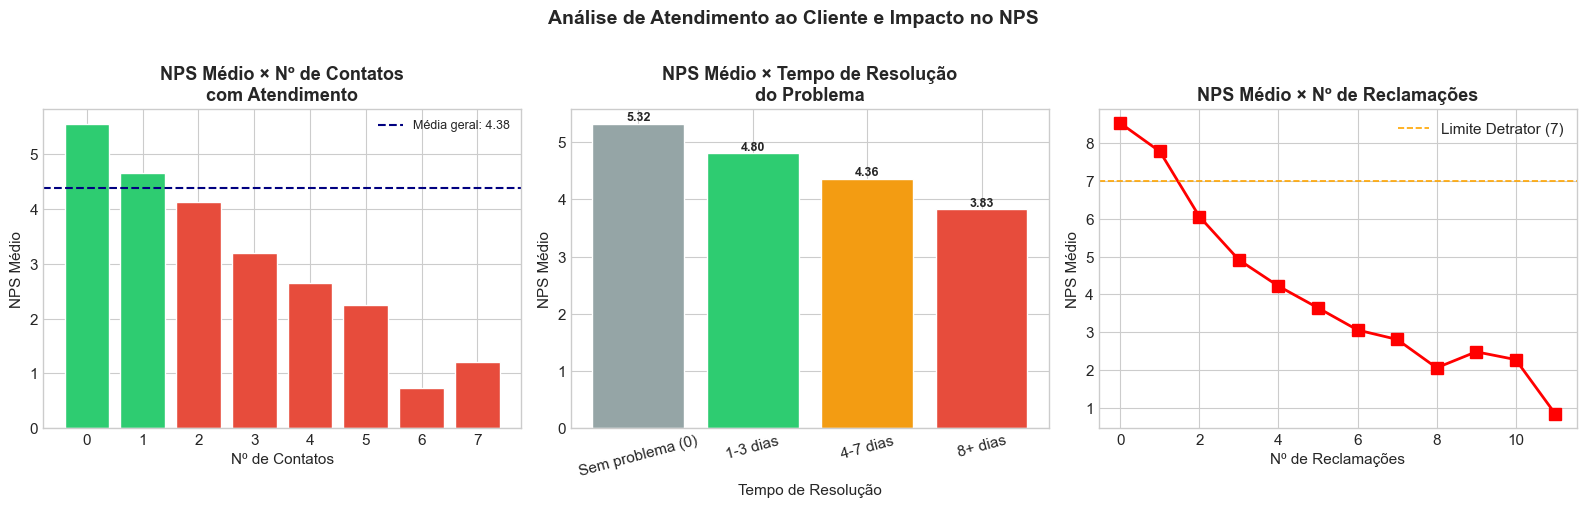

CORRELAÇÕES COM NPS SCORE:
  Contatos atendimento  : r = -0.351  (p = 0.0000)
  Tempo de resolução    : r = -0.191  (p = 0.0000)
  Nº de reclamações     : r = -0.497  (p = 0.0000)


In [8]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. NPS por nº de contatos com atendimento
nps_contatos = df.groupby('customer_service_contacts')['nps_score'].mean()
cores_cont = ['#2ecc71' if v >= df['nps_score'].mean() else '#e74c3c' for v in nps_contatos.values]
axes[0].bar(nps_contatos.index, nps_contatos.values, color=cores_cont, edgecolor='white')
axes[0].axhline(y=df['nps_score'].mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Média geral: {df["nps_score"].mean():.2f}')
axes[0].set_title('NPS Médio × Nº de Contatos\ncom Atendimento')
axes[0].set_xlabel('Nº de Contatos')
axes[0].set_ylabel('NPS Médio')
axes[0].legend(fontsize=9)

# 2. NPS por faixa de tempo de resolução
df['faixa_resolucao'] = pd.cut(df['resolution_time_days'],
                                bins=[-1, 0, 3, 7, 100],
                                labels=['Sem problema (0)', '1-3 dias', '4-7 dias', '8+ dias'])
nps_res = df.groupby('faixa_resolucao', observed=True)['nps_score'].mean()
axes[1].bar(nps_res.index, nps_res.values,
             color=['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[1].set_title('NPS Médio × Tempo de Resolução\ndo Problema')
axes[1].set_xlabel('Tempo de Resolução')
axes[1].set_ylabel('NPS Médio')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(nps_res.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

# 3. NPS por nº de reclamações
nps_reclam = df.groupby('complaints_count')['nps_score'].mean()
axes[2].plot(nps_reclam.index, nps_reclam.values, 'rs-', markersize=8, linewidth=2)
axes[2].axhline(y=7, color='orange', linestyle='--', linewidth=1.2, label='Limite Detrator (7)')
axes[2].set_title('NPS Médio × Nº de Reclamações')
axes[2].set_xlabel('Nº de Reclamações')
axes[2].set_ylabel('NPS Médio')
axes[2].legend()

plt.suptitle('Análise de Atendimento ao Cliente e Impacto no NPS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

corr_cont, p_cont = stats.pearsonr(df['customer_service_contacts'], df['nps_score'])
corr_res,  p_res  = stats.pearsonr(df['resolution_time_days'],       df['nps_score'])
corr_rec,  p_rec  = stats.pearsonr(df['complaints_count'],            df['nps_score'])
print("CORRELAÇÕES COM NPS SCORE:")
print(f"  Contatos atendimento  : r = {corr_cont:+.3f}  (p = {p_cont:.4f})")
print(f"  Tempo de resolução    : r = {corr_res:+.3f}  (p = {p_res:.4f})")
print(f"  Nº de reclamações     : r = {corr_rec:+.3f}  (p = {p_rec:.4f})")

## 1.5 Perfil do Cliente — Quem Tende a Ter NPS Alto ou Baixo?

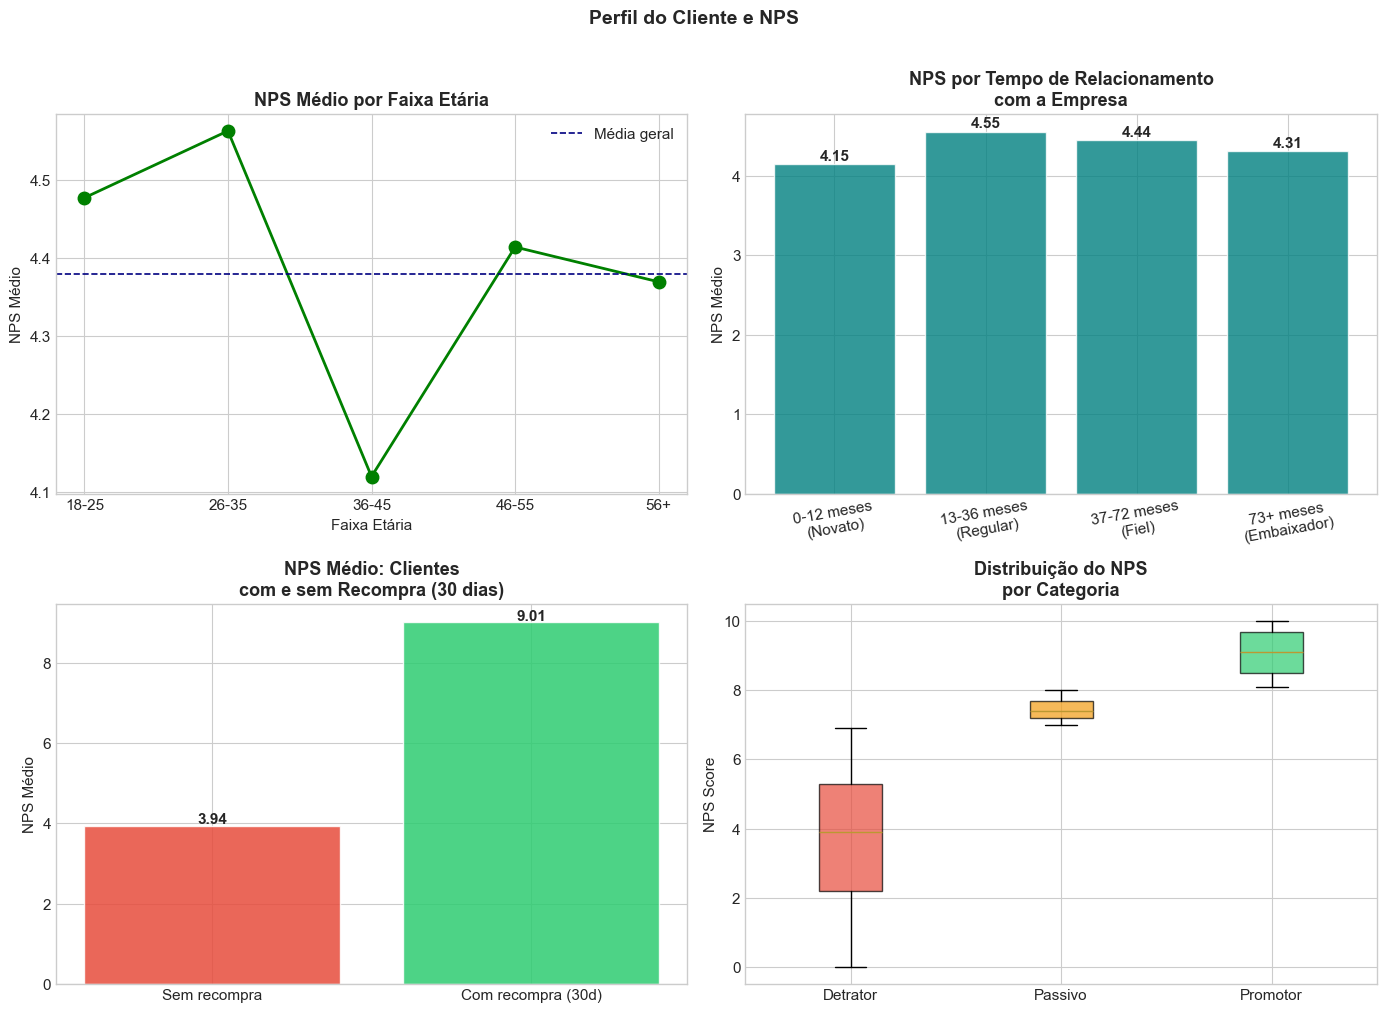

Clientes que recompraram em 30 dias: 218 (8.7% da base)


In [9]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. NPS por faixa etária
df['faixa_idade'] = pd.cut(df['customer_age'],
                            bins=[0, 25, 35, 45, 55, 100],
                            labels=['18-25', '26-35', '36-45', '46-55', '56+'])
nps_idade = df.groupby('faixa_idade', observed=True)['nps_score'].mean()
axes[0,0].plot(nps_idade.index, nps_idade.values, 'go-', markersize=9, linewidth=2)
axes[0,0].axhline(y=df['nps_score'].mean(), color='navy', linestyle='--', linewidth=1.2,
                   label='Média geral')
axes[0,0].set_title('NPS Médio por Faixa Etária')
axes[0,0].set_ylabel('NPS Médio')
axes[0,0].set_xlabel('Faixa Etária')
axes[0,0].legend()

# 2. NPS por tempo de relacionamento
df['faixa_tenure'] = pd.cut(df['customer_tenure_months'],
                              bins=[0, 12, 36, 72, 9999],
                              labels=['0-12 meses\n(Novato)', '13-36 meses\n(Regular)',
                                      '37-72 meses\n(Fiel)', '73+ meses\n(Embaixador)'])
nps_tenure = df.groupby('faixa_tenure', observed=True)['nps_score'].mean()
axes[0,1].bar(nps_tenure.index, nps_tenure.values, color='teal', alpha=0.8, edgecolor='white')
axes[0,1].set_title('NPS por Tempo de Relacionamento\ncom a Empresa')
axes[0,1].set_ylabel('NPS Médio')
axes[0,1].tick_params(axis='x', rotation=10)
for i, v in enumerate(nps_tenure.values):
    axes[0,1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# 3. NPS por recompra em 30 dias
nps_recompra = df.groupby('repeat_purchase_30d')['nps_score'].mean()
labels_rc    = {0: 'Sem recompra', 1: 'Com recompra (30d)'}
vals_rc = [nps_recompra.get(k, 0) for k in [0, 1]]
bars = axes[1,0].bar([labels_rc[0], labels_rc[1]], vals_rc,
                       color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='white')
axes[1,0].set_title('NPS Médio: Clientes\ncom e sem Recompra (30 dias)')
axes[1,0].set_ylabel('NPS Médio')
for bar in bars:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                   f'{bar.get_height():.2f}', ha='center', fontweight='bold')

# 4. Boxplot NPS por categoria
nps_by_cat = [df[df['nps_categoria'] == c]['nps_score'].values
              for c in ['Detrator', 'Passivo', 'Promotor']]
bp = axes[1,1].boxplot(nps_by_cat, labels=['Detrator', 'Passivo', 'Promotor'],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], ['#e74c3c', '#f39c12', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,1].set_title('Distribuição do NPS\npor Categoria')
axes[1,1].set_ylabel('NPS Score')

plt.suptitle('Perfil do Cliente e NPS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Clientes que recompraram em 30 dias: {df['repeat_purchase_30d'].sum()} "
      f"({df['repeat_purchase_30d'].mean()*100:.1f}% da base)")

## 1.6 Correlações — O que Mais Explica o NPS?

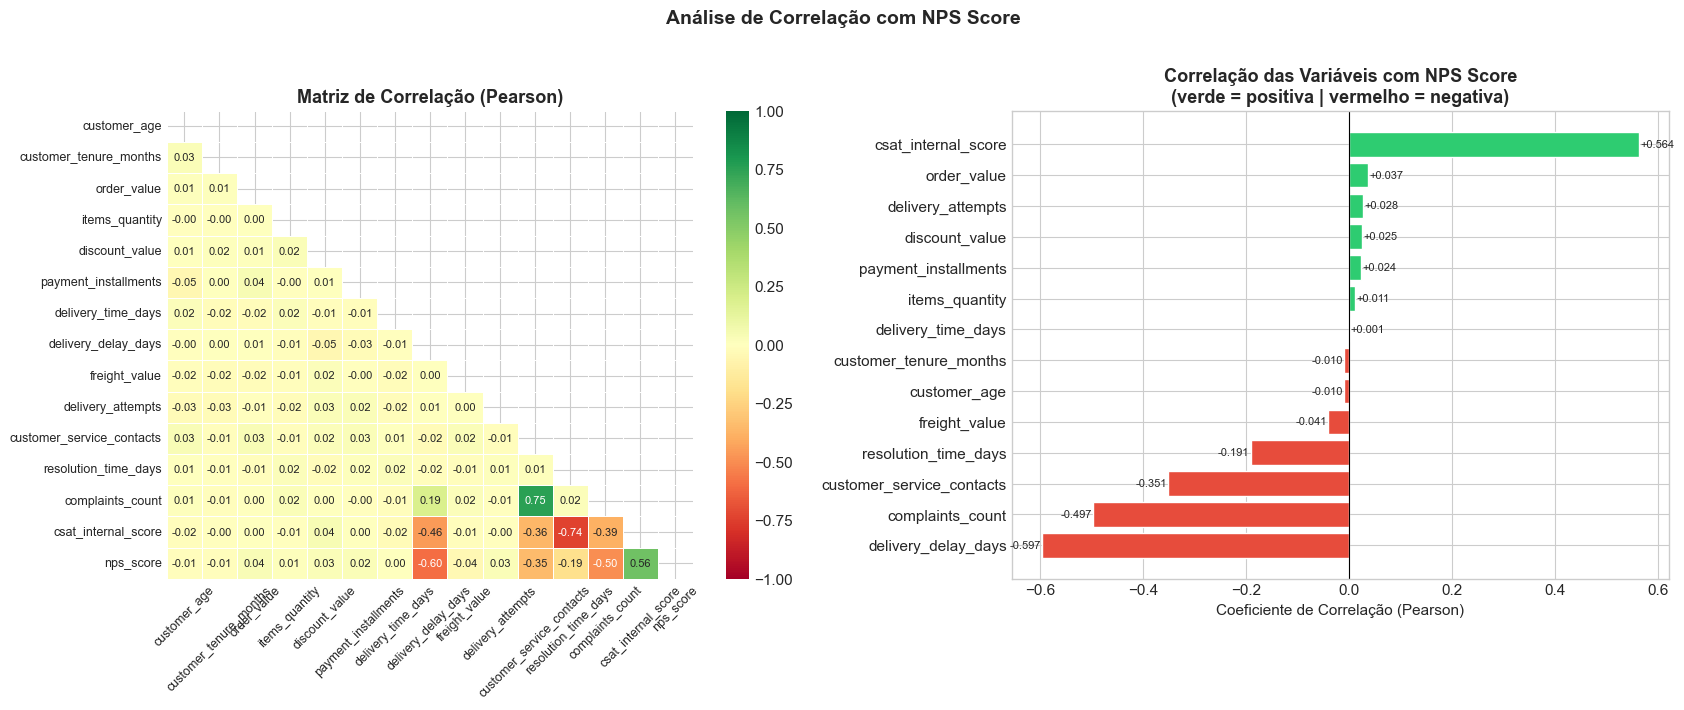

Top 5 correlações POSITIVAS com NPS:
csat_internal_score     0.563952
order_value             0.036990
delivery_attempts       0.027680
discount_value          0.025104
payment_installments    0.023718

Top 5 correlações NEGATIVAS com NPS:
delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087


In [10]:
features_num = [
    'customer_age', 'customer_tenure_months',
    'order_value', 'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts',
    'resolution_time_days', 'complaints_count',
    'csat_internal_score', 'nps_score'
]

corr_matrix = df[features_num].corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Matriz de Correlação (Pearson)')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', labelsize=9)

# Ranking de correlação com NPS
corr_nps = corr_matrix['nps_score'].drop('nps_score').sort_values()
cores_corr = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_nps.values]
axes[1].barh(corr_nps.index, corr_nps.values, color=cores_corr, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Correlação das Variáveis com NPS Score\n(verde = positiva | vermelho = negativa)')
axes[1].set_xlabel('Coeficiente de Correlação (Pearson)')
for i, v in enumerate(corr_nps.values):
    axes[1].text(v + (0.002 if v >= 0 else -0.002), i,
                 f'{v:+.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)

plt.suptitle('Análise de Correlação com NPS Score', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Top 5 correlações POSITIVAS com NPS:")
print(corr_nps.tail(5).sort_values(ascending=False).to_string())
print("\nTop 5 correlações NEGATIVAS com NPS:")
print(corr_nps.head(5).to_string())

## 1.6b — CSAT Interno (`csat_internal_score`)

O dataset contém um score de satisfação interno (`csat_internal_score`) além do NPS. É a variável com **maior correlação linear positiva com o NPS (r = +0,56)** — o que levanta suspeita de leakage, já que pode ter sido coletado na mesma pesquisa ou ser derivado do próprio NPS. A análise abaixo caracteriza sua distribuição e relação com as categorias de NPS.

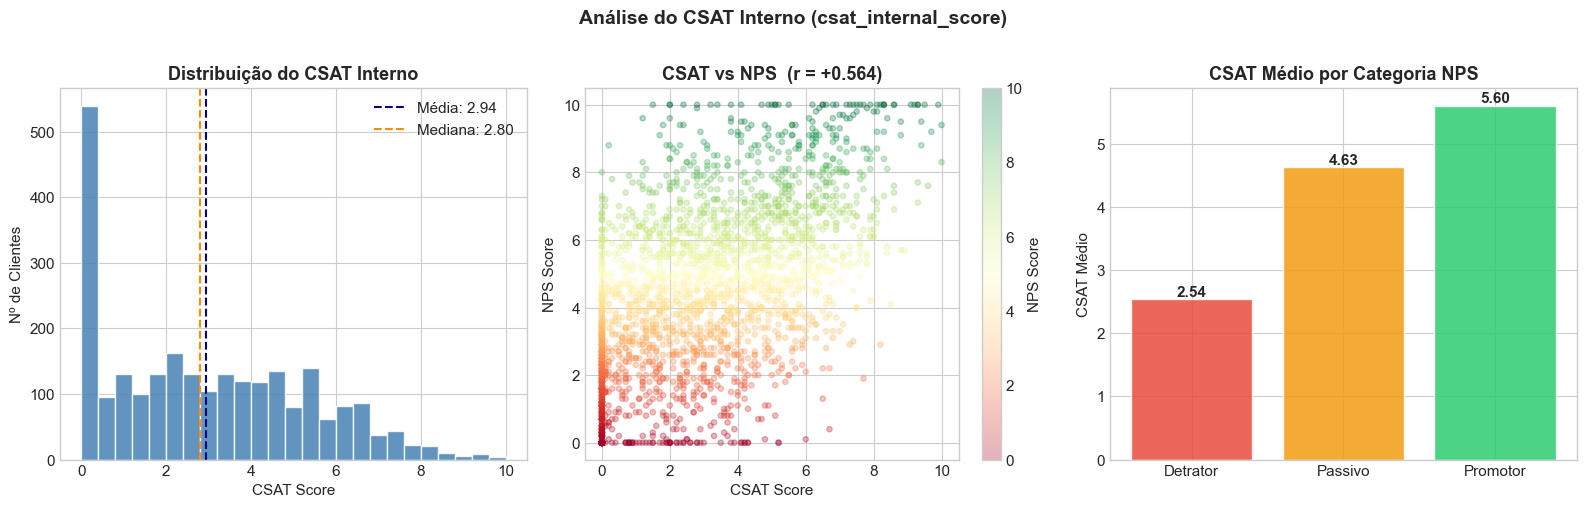

CSAT INTERNO — ESTATÍSTICAS:
  Escala        : 0.0 a 10.0
  Média         : 2.94
  Mediana       : 2.80
  Desvio padrão : 2.38

CSAT MÉDIO POR CATEGORIA NPS:
  Detrator  : 2.54  (n = 2109)
  Passivo   : 4.63  (n = 190)
  Promotor  : 5.60  (n = 201)

Correlação CSAT x NPS : r = +0.564  (p = 0.0000)

ATENCAO — RISCO DE DATA LEAKAGE:
  Com r = +0,56 e sendo a variavel de maior correlacao linear com o NPS,
  o csat_internal_score provavelmente e coletado na mesma pesquisa ou
  derivado do proprio NPS. Usar em modelos sem verificar a origem e o
  momento de coleta pode inflar artificialmente a performance do modelo.


In [14]:
# =============================================================================
# CSAT INTERNO — ANÁLISE DETALHADA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribuição do CSAT
axes[0].hist(df['csat_internal_score'], bins=25, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(x=df['csat_internal_score'].mean(), color='navy',
                linestyle='--', linewidth=1.5,
                label=f'Média: {df["csat_internal_score"].mean():.2f}')
axes[0].axvline(x=df['csat_internal_score'].median(), color='darkorange',
                linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["csat_internal_score"].median():.2f}')
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Nº de Clientes')
axes[0].set_title('Distribuição do CSAT Interno')
axes[0].legend()

# 2. Scatter CSAT vs NPS
sc = axes[1].scatter(df['csat_internal_score'], df['nps_score'],
                     alpha=0.3, s=15, c=df['nps_score'], cmap='RdYlGn')
plt.colorbar(sc, ax=axes[1], label='NPS Score')
axes[1].set_xlabel('CSAT Score')
axes[1].set_ylabel('NPS Score')
corr_csat, p_csat = stats.pearsonr(df['csat_internal_score'], df['nps_score'])
axes[1].set_title(f'CSAT vs NPS  (r = {corr_csat:+.3f})')

# 3. CSAT médio por categoria NPS
cat_order   = ['Detrator', 'Passivo', 'Promotor']
csat_by_cat = df.groupby('nps_categoria')['csat_internal_score'].mean()
vals        = [csat_by_cat.get(c, 0) for c in cat_order]
axes[2].bar(cat_order, vals,
            color=['#e74c3c', '#f39c12', '#2ecc71'],
            alpha=0.85, edgecolor='white')
axes[2].set_title('CSAT Médio por Categoria NPS')
axes[2].set_ylabel('CSAT Médio')
for i, v in enumerate(vals):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Análise do CSAT Interno (csat_internal_score)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Estatísticas
print('CSAT INTERNO — ESTATÍSTICAS:')
print(f'  Escala        : {df["csat_internal_score"].min():.1f} a {df["csat_internal_score"].max():.1f}')
print(f'  Média         : {df["csat_internal_score"].mean():.2f}')
print(f'  Mediana       : {df["csat_internal_score"].median():.2f}')
print(f'  Desvio padrão : {df["csat_internal_score"].std():.2f}')
print()
print('CSAT MÉDIO POR CATEGORIA NPS:')
for cat in cat_order:
    n   = (df['nps_categoria'] == cat).sum()
    val = csat_by_cat.get(cat, 0)
    print(f'  {cat:10s}: {val:.2f}  (n = {n})')
print()
print(f'Correlação CSAT x NPS : r = {corr_csat:+.3f}  (p = {p_csat:.4f})')
print()
print('ATENCAO — RISCO DE DATA LEAKAGE:')
print('  Com r = +0,56 e sendo a variavel de maior correlacao linear com o NPS,')
print('  o csat_internal_score provavelmente e coletado na mesma pesquisa ou')
print('  derivado do proprio NPS. Usar em modelos sem verificar a origem e o')
print('  momento de coleta pode inflar artificialmente a performance do modelo.')


## 1.7 Pontos de Ruptura — Onde a Experiência do Cliente "Quebra"?

Investigar em que patamar de atraso ou de contatos o NPS médio cai para a zona de detração (< 7) ajuda a definir SLAs operacionais. Contudo, os dados revelam um cenário mais crítico: com NPS médio geral de **4,38**, o patamar de detração já está estabelecido **independentemente de atrasos ou contatos**. Os gráficos abaixo confirmam: mesmo com **zero dias de atraso** e **zero contatos com atendimento**, o NPS médio permanece abaixo de 7. Isso indica que o problema é **estrutural**, as variáveis operacionais aprofundam a insatisfação, mas não são sua causa exclusiva.

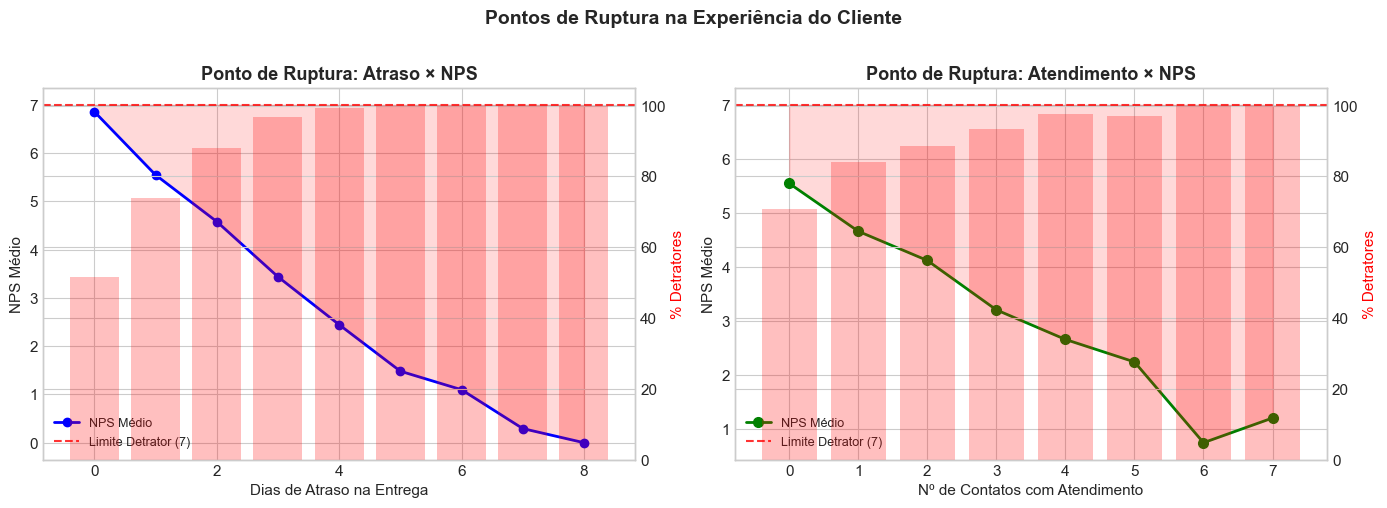

LIMIARES CRÍTICOS IDENTIFICADOS:
  → Atraso na entrega ≥ 0 dias: NPS médio cai abaixo de 7 (zona de detração)
  → A partir de 0 contato(s) com atendimento: NPS médio cai abaixo de 7


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Ponto de ruptura: atraso na entrega
atraso_vals = sorted(df['delivery_delay_days'].unique())
nps_por_atraso = df.groupby('delivery_delay_days')['nps_score'].mean()
pct_detr_atraso = df.groupby('delivery_delay_days').apply(
    lambda x: (x['nps_categoria'] == 'Detrator').mean() * 100)

ax1_twin = axes[0].twinx()
axes[0].plot(nps_por_atraso.index, nps_por_atraso.values, 'bo-', markersize=6, linewidth=2, label='NPS Médio')
axes[0].axhline(y=7, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Limite Detrator (7)')
axes[0].fill_between(nps_por_atraso.index, nps_por_atraso.values, 7,
                      where=(nps_por_atraso.values < 7), alpha=0.15, color='red')
ax1_twin.bar(pct_detr_atraso.index, pct_detr_atraso.values, alpha=0.25, color='red', label='% Detratores')
ax1_twin.set_ylabel('% Detratores', color='red')
axes[0].set_xlabel('Dias de Atraso na Entrega')
axes[0].set_ylabel('NPS Médio')
axes[0].set_title('Ponto de Ruptura: Atraso × NPS')
axes[0].legend(loc='lower left', fontsize=9)

# 2. Ponto de ruptura: contatos de atendimento
nps_por_cont = df.groupby('customer_service_contacts')['nps_score'].mean()
pct_detr_cont = df.groupby('customer_service_contacts').apply(
    lambda x: (x['nps_categoria'] == 'Detrator').mean() * 100)

ax2_twin = axes[1].twinx()
axes[1].plot(nps_por_cont.index, nps_por_cont.values, 'go-', markersize=7, linewidth=2, label='NPS Médio')
axes[1].axhline(y=7, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Limite Detrator (7)')
axes[1].fill_between(nps_por_cont.index, nps_por_cont.values, 7,
                      where=(nps_por_cont.values < 7), alpha=0.15, color='red')
ax2_twin.bar(pct_detr_cont.index, pct_detr_cont.values, alpha=0.25, color='red', label='% Detratores')
ax2_twin.set_ylabel('% Detratores', color='red')
axes[1].set_xlabel('Nº de Contatos com Atendimento')
axes[1].set_ylabel('NPS Médio')
axes[1].set_title('Ponto de Ruptura: Atendimento × NPS')
axes[1].legend(loc='lower left', fontsize=9)

plt.suptitle('Pontos de Ruptura na Experiência do Cliente', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Resumo dos limiares críticos
print("LIMIARES CRÍTICOS IDENTIFICADOS:")
atraso_critico = nps_por_atraso[nps_por_atraso < 7].index.min()
cont_critico   = nps_por_cont[nps_por_cont < 7].index.min()
if pd.notna(atraso_critico):
    print(f"  → Atraso na entrega ≥ {atraso_critico} dias: NPS médio cai abaixo de 7 (zona de detração)")
if pd.notna(cont_critico):
    print(f"  → A partir de {cont_critico} contato(s) com atendimento: NPS médio cai abaixo de 7")

In [12]:
# =============================================================================
# NPS DOS CLIENTES SEM ATRASO NA ENTREGA
# Confirma se a insatisfação é estrutural ou apenas gerada por atrasos
# =============================================================================

sem_atraso = df[df['delivery_delay_days'] == 0].copy()

n_total      = len(sem_atraso)
n_detratores = (sem_atraso['nps_categoria'] == 'Detrator').sum()
n_neutros    = (sem_atraso['nps_categoria'] == 'Passivo').sum()
n_promotores = (sem_atraso['nps_categoria'] == 'Promotor').sum()
nps_medio    = sem_atraso['nps_score'].mean()
nps_mediana  = sem_atraso['nps_score'].median()
nps_score_sa = (n_promotores - n_detratores) / n_total * 100

# Comparativo com a base completa
n_total_base      = len(df)
n_detr_base       = (df['nps_categoria'] == 'Detrator').sum()
n_neutr_base      = (df['nps_categoria'] == 'Passivo').sum()
n_prom_base       = (df['nps_categoria'] == 'Promotor').sum()
nps_score_base    = (n_prom_base - n_detr_base) / n_total_base * 100

print('=' * 60)
print('CLIENTES SEM ATRASO NA ENTREGA (delivery_delay_days = 0)')
print('=' * 60)
print(f'  Total de clientes : {n_total} ({n_total/n_total_base*100:.1f}% da base)')
print(f'  NPS médio         : {nps_medio:.2f}')
print(f'  NPS mediana       : {nps_mediana:.2f}')
print(f'  NPS Score         : {nps_score_sa:.1f} pontos')
print()
print(f'  Promotores : {n_promotores:>5} ({n_promotores/n_total*100:.1f}%)')
print(f'  Neutros    : {n_neutros:>5} ({n_neutros/n_total*100:.1f}%)')
print(f'  Detratores : {n_detratores:>5} ({n_detratores/n_total*100:.1f}%)')
print()
print('=' * 60)
print('COMPARATIVO — BASE COMPLETA')
print('=' * 60)
print(f'  Total de clientes : {n_total_base}')
print(f'  NPS médio         : {df["nps_score"].mean():.2f}')
print(f'  NPS mediana       : {df["nps_score"].median():.2f}')
print(f'  NPS Score         : {nps_score_base:.1f} pontos')
print()
print(f'  Promotores : {n_prom_base:>5} ({n_prom_base/n_total_base*100:.1f}%)')
print(f'  Neutros    : {n_neutr_base:>5} ({n_neutr_base/n_total_base*100:.1f}%)')
print(f'  Detratores : {n_detr_base:>5} ({n_detr_base/n_total_base*100:.1f}%)')
print()
print(f'→ Mesmo sem nenhum atraso, o NPS Score é {nps_score_sa:.1f} confirmando que'
      f' a insatisfação é estrutural.')


CLIENTES SEM ATRASO NA ENTREGA (delivery_delay_days = 0)
  Total de clientes : 277 (11.1% da base)
  NPS médio         : 6.86
  NPS mediana       : 6.80
  NPS Score         : -20.6 pontos

  Promotores :    86 (31.0%)
  Neutros    :    48 (17.3%)
  Detratores :   143 (51.6%)

COMPARATIVO — BASE COMPLETA
  Total de clientes : 2500
  NPS médio         : 4.38
  NPS mediana       : 4.40
  NPS Score         : -76.3 pontos

  Promotores :   201 (8.0%)
  Neutros    :   190 (7.6%)
  Detratores :  2109 (84.4%)

→ Mesmo sem nenhum atraso, o NPS Score é -20.6 confirmando que a insatisfação é estrutural.


## 1.8 Insights de Negócio — Resumo Executivo da EDA

### O que mais gera detratores?

Os dados confirmaram alguns fatores e derrubaram outros. Abaixo, o ranking por força de correlação com o NPS:

| Fator | r com NPS | Observação | Ação Recomendada |
|---|---|---|---|
| **Atraso na entrega** | −0,60 | Driver mais forte. O prazo absoluto não importa — só o cumprimento do prometido | Monitoramento preditivo por pedido; contato proativo quando risco de atraso é detectado |
| **Nº de reclamações** | −0,50 | Segunda maior correlação negativa | Canal de escalonamento para clientes com ≥ 2 reclamações |
| **Contatos com atendimento** | −0,35 | Cada contato adicional aprofunda a insatisfação | Investir em resolução no primeiro contato (FCR) e autoatendimento eficaz |
| **Tempo de resolução** | −0,19 | Efeito menor, mas consistente e significativo (p < 0,0001) | SLA de resolução máxima de 3 dias para casos críticos |
| **Tempo total de entrega** | ≈ 0,00 | **Sem correlação com NPS** | Comunicar prazos realistas; o que gera insatisfação é o descumprimento, não o prazo em si |
| **Tentativas de entrega** | +0,03 | **Sem relevância** preditiva neste dataset | — |

### O problema é sistêmico, não pontual

> **Achado crítico:** NPS Score de **−76,3 pontos**, com **84,4% de detratores** e apenas 8,0% de promotores. Mais grave: o NPS médio está abaixo de 7 **mesmo em pedidos sem atraso e sem contatos com atendimento**. A insatisfação não é gerada apenas por falhas operacionais. Ela é o estado padrão da experiência do cliente.

### Que tipo de cliente tende a ter NPS mais alto?

- Apenas **8,7% da base** (218 clientes) recomprou em 30 dias. Esses clientes têm NPS consistentemente mais alto — reflexo natural: quem ficou satisfeito voltou a comprar.
- As diferenças de NPS por **região geográfica são mínimas**: de 4,21 (Centro-Oeste) a 4,49 (Sul) — variação de apenas 0,28 pontos. **Não há região especialmente problemática.**
- Faixa etária e tempo de relacionamento (*tenure*) têm impacto marginal no NPS — os fatores operacionais dominam.

### Existe algum "ponto de ruptura" na experiência?

Não da forma esperada. Com **0 dias de atraso**, o NPS médio já está na zona de detração. Com **0 contatos** com atendimento, idem. Não há um gatilho isolado que "quebra" a experiência. Ela já está estruturalmente comprometida. As variáveis operacionais (especialmente atraso e reclamações) aprofundam ainda mais a insatisfação, mas não são sua causa exclusiva.